In [ ]:
#installation
!pip install torch_geometric
!pip install optuna
#torch_geomteric is for building and training gnn
#optuna is hyperparameter frameowrk to automate tuning of models

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 15.7 MB/s eta 0:00:00


In [ ]:
#imports
import torch
from torch_geometric.datasets import KarateClub
from torch_geometric.utils import to_networkx #converting dataset into netwrokx for visualizing
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from torch.nn import Linear
from torch_geometric.nn import GCNConv

In [ ]:
#loading dataset
dataset = KarateClub()
data = dataset[0]

In [ ]:
print(dataset.num_features)


34


In [ ]:
import pandas as pd

# converting node features to pandas dataframe
nf_df = pd.DataFrame(
    data.x.numpy(),
    columns=[f'feature_{i}' for i in range(data.x.shape[1])]
)

nf_df['node'] = nf_df.index
nf_df.set_index('node', inplace=True)


# converting edge indices to pandas dataframe
ed_index_df = pd.DataFrame(
    data.edge_index.numpy().T,
    columns=['source', 'target']
)


# convert labels to pandas dataframe
labels_df = pd.DataFrame(
    data.y.numpy(),
    columns=['label']
)

labels_df['node'] = labels_df.index
labels_df.set_index('node', inplace=True)

In [ ]:
print(nf_df)

      feature_0  feature_1  feature_2  ...  feature_31  feature_32  feature_33
node                                   ...                                    
0           1.0        0.0        0.0  ...         0.0         0.0         0.0
1           0.0        1.0        0.0  ...         0.0         0.0         0.0
2           0.0        0.0        1.0  ...         0.0         0.0         0.0
3           0.0        0.0        0.0  ...         0.0         0.0         0.0
4           0.0        0.0        0.0  ...         0.0         0.0         0.0
5           0.0        0.0        0.0  ...         0.0         0.0         0.0
6           0.0        0.0        0.0  ...         0.0         0.0         0.0
7           0.0        0.0        0.0  ...         0.0         0.0         0.0
8           0.0        0.0        0.0  ...         0.0         0.0         0.0
9           0.0        0.0        0.0  ...         0.0         0.0         0.0
10          0.0        0.0        0.0  ...         0

In [ ]:
#print number of nodes
num_nodes = data.num_nodes
print(f"Number of nodes:{num_nodes}")

Number of nodes:34


In [ ]:
#print number of edges
num_edges = data.edge_index.shape[1]
print(f"Number of edges:{num_edges}")

Number of edges:156


In [ ]:
#print node fetaure df
print(f"\nNode feature(shape:{nf_df.shape}):")
print(nf_df.head()) #prints only first few rows for brevity(state of being short or quick)


Node feature(shape:(34, 34)):
      feature_0  feature_1  feature_2  ...  feature_31  feature_32  feature_33
node                                   ...                                    
0           1.0        0.0        0.0  ...         0.0         0.0         0.0
1           0.0        1.0        0.0  ...         0.0         0.0         0.0
2           0.0        0.0        1.0  ...         0.0         0.0         0.0
3           0.0        0.0        0.0  ...         0.0         0.0         0.0
4           0.0        0.0        0.0  ...         0.0         0.0         0.0

[5 rows x 34 columns]


In [ ]:
#print edge indices dataframe
print(f"\nEdge indices(shape:{ed_index_df.shape}):")
print(ed_index_df.head())


Edge indices(shape:(156, 2)):
   source  target
0       0       1
1       0       2
2       0       3
3       0       4
4       0       5


In [ ]:
#print labels dataframe
print(f"\nLabels (shape: {labels_df.shape}):")
print(labels_df.head())


Labels (shape: (34, 1)):
      label
node       
0         1
1         1
2         1
3         1
4         3


In [ ]:
#number of countries
num_countries = 4
#assign students to countires(labels)
np.random.seed(42)
countries = torch.tensor(np.random.choice(num_countries,data.num_nodes))

#update labels in the data object
data.y = countries

In [ ]:
#verify data
print(data)
print(f'x = {data.x.shape}')
print(data.x)
print(f'edge_index = {data.edge_index.shape}')
print(data.edge_index)
print(f'y={data.y.shape}')
print(data.y)

Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
x = torch.Size([34, 34])
tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])
edge_index = torch.Size([2, 156])
tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,
          3,  3,  3,  3,  3,  4,  4,  4,  5,  5,  5,  5,  6,  6,  6,  6,  7,  7,
          7,  7,  8,  8,  8,  8,  8,  9,  9, 10, 10, 10, 11, 12, 12, 13, 13, 13,
         13, 13, 14, 14, 15, 15, 16, 16, 17, 17, 18, 18, 19, 19, 19, 20, 20, 21,
         21, 22, 22, 23, 23, 23, 23, 23, 24, 24, 24, 25, 25, 25, 26, 26, 27, 27,
         27, 27, 28, 28, 28, 29, 29, 29, 29, 30, 30, 30, 30, 31, 31, 31, 31, 31,
         31, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 

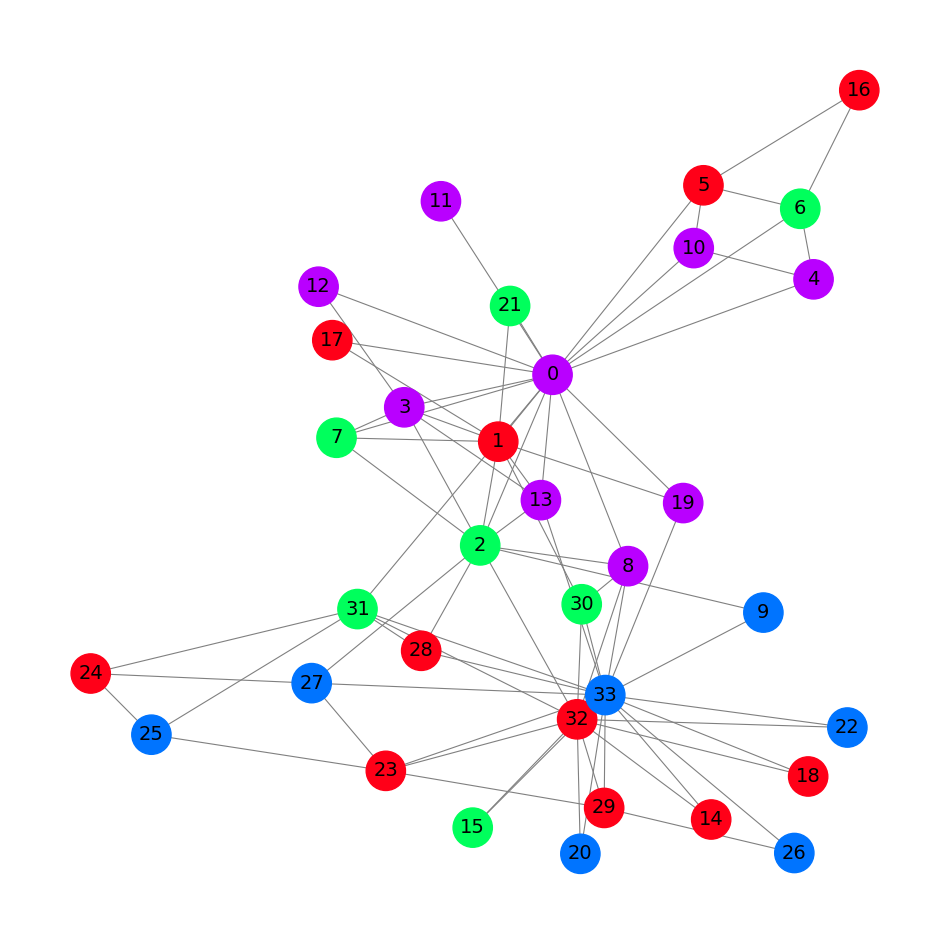

In [ ]:
#check iif the graph is as expected
G = to_networkx(data,to_undirected=True)
plt.figure(figsize=(12,12))
plt.axis('off')
nx.draw_networkx(G,
                 pos=nx.spring_layout(G,seed=0),
                 with_labels = True,
                 node_size=800,
                 node_color=data.y,
                 cmap="hsv",
                 vmin=-2,
                 vmax=3,
                 width=0.8,
                 edge_color="grey",
                 font_size=14
                 )
plt.show()

In [ ]:
class GCN(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.gcn = GCNConv(dataset.num_features,3)
    self.out = Linear(3,num_countries)

  def forward(self,x,edge_index):
    h=self.gcn(x,edge_index).relu()
    z = self.out(h)
    return h,z
model = GCN()
print(model)

GCN(
  (gcn): GCNConv(34, 3)
  (out): Linear(in_features=3, out_features=4, bias=True)
)


In [ ]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.02)

#calculate accuracy
def accuracy(pred_y,y):
  return (pred_y == y).sum()/len(y)


In [ ]:
#data for animations
embeddings = []
losses = []
accuracies = []
outputs = []

#training loop
for epoch in range(200):
  optimizer.zero_grad()
  h,z = model(data.x,data.edge_index)
  loss = criterion(z,data.y)
  acc = accuracy(z.argmax(dim=1),data.y)
  loss.backward()
  optimizer.step()
  embeddings.append(h)
  losses.append(loss)
  accuracies.append(acc)
  outputs.append(z.argmax(dim=1))
  if epoch % 10 == 0:
    print(f'Epoch {epoch:>3} | Loss: {loss:.2f} | Acc : {acc*100:.2f}%')



Epoch   0 | Loss: 1.49 | Acc : 26.47%
Epoch  10 | Loss: 1.34 | Acc : 26.47%
Epoch  20 | Loss: 1.22 | Acc : 47.06%
Epoch  30 | Loss: 1.11 | Acc : 50.00%
Epoch  40 | Loss: 0.97 | Acc : 67.65%
Epoch  50 | Loss: 0.80 | Acc : 73.53%
Epoch  60 | Loss: 0.62 | Acc : 79.41%
Epoch  70 | Loss: 0.48 | Acc : 85.29%
Epoch  80 | Loss: 0.38 | Acc : 88.24%
Epoch  90 | Loss: 0.30 | Acc : 88.24%
Epoch 100 | Loss: 0.24 | Acc : 94.12%
Epoch 110 | Loss: 0.20 | Acc : 100.00%
Epoch 120 | Loss: 0.16 | Acc : 100.00%
Epoch 130 | Loss: 0.14 | Acc : 100.00%
Epoch 140 | Loss: 0.11 | Acc : 100.00%
Epoch 150 | Loss: 0.10 | Acc : 100.00%
Epoch 160 | Loss: 0.08 | Acc : 100.00%
Epoch 170 | Loss: 0.07 | Acc : 100.00%
Epoch 180 | Loss: 0.06 | Acc : 100.00%
Epoch 190 | Loss: 0.05 | Acc : 100.00%


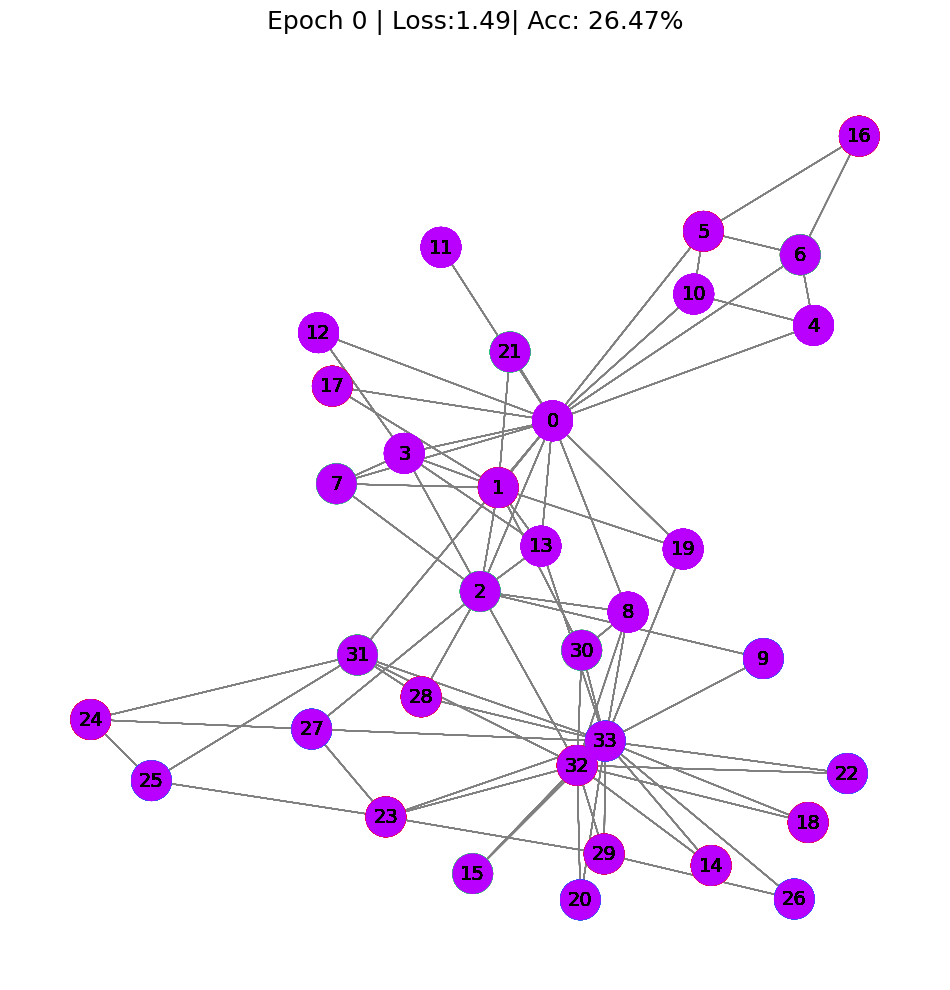

In [29]:
#visualizing training process
from IPython.display import HTML
from matplotlib import animation
plt.rcParams["animation.bitrate"] = 3000

def animate(i):
  G = to_networkx(data,to_undirected=True)
  nx.draw_networkx(G,
                   pos=nx.spring_layout(G,seed=0),
                   with_labels=True,
                   node_size=800,
                   node_color=outputs[i].numpy(),
                   cmap="hsv",
                   vmin=-2,
                   vmax=3,
                   width=0.8,
                   edge_color="grey",
                   font_size=14
                   )
  plt.title(f'Epoch {i} | Loss:{losses[i].item():.2f}| Acc: {accuracies[i].item()*100:.2f}%',fontsize=18,pad=20)

fig=plt.figure(figsize=(12,12))
plt.axis('off')
anim=animation.FuncAnimation(fig,animate,np.arange(0,200,10),interval=500,repeat=True)
html = HTML(anim.to_html5_video())
display(html)

Final Embeddings = torch.Size([34, 3])
tensor([[6.5889e-01, 0.0000e+00, 2.2728e+00],
        [1.8246e+00, 0.0000e+00, 1.7280e+00],
        [9.6645e-01, 0.0000e+00, 0.0000e+00],
        [3.3495e-01, 0.0000e+00, 1.3085e+00],
        [4.7439e-02, 0.0000e+00, 1.3552e+00],
        [1.2772e+00, 8.7926e-01, 1.1829e+00],
        [1.4366e+00, 1.1478e-03, 2.4186e-01],
        [1.4305e+00, 0.0000e+00, 2.2189e-01],
        [3.7111e-01, 0.0000e+00, 1.1447e+00],
        [0.0000e+00, 2.1412e+00, 5.3438e-01],
        [7.1419e-02, 0.0000e+00, 1.4145e+00],
        [0.0000e+00, 0.0000e+00, 1.6754e+00],
        [0.0000e+00, 0.0000e+00, 1.5353e+00],
        [2.5293e-01, 9.4421e-02, 1.5002e+00],
        [1.5908e+00, 1.3618e+00, 8.9696e-01],
        [1.5321e+00, 0.0000e+00, 0.0000e+00],
        [2.1242e+00, 1.1145e+00, 2.4954e-01],
        [2.1357e+00, 8.8550e-01, 1.3293e+00],
        [1.5460e+00, 1.2580e+00, 1.0030e+00],
        [2.7066e-02, 8.2332e-04, 1.2899e+00],
        [0.0000e+00, 1.4766e+00, 6.7261e-

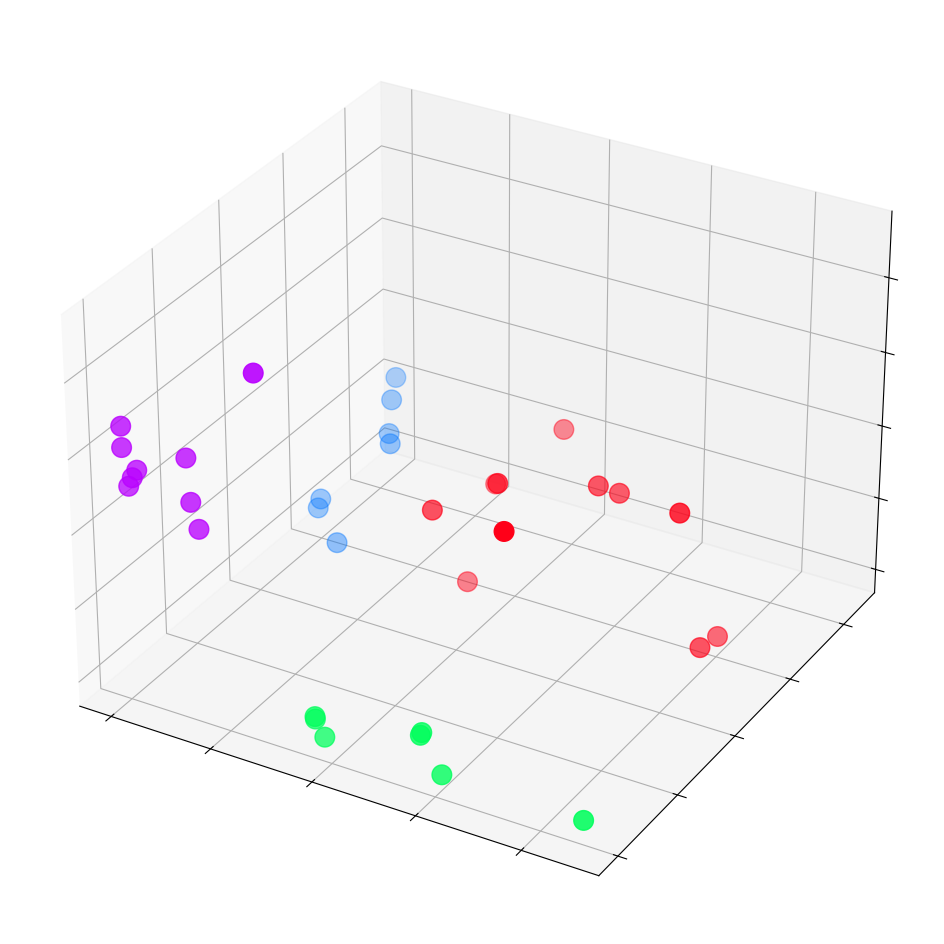

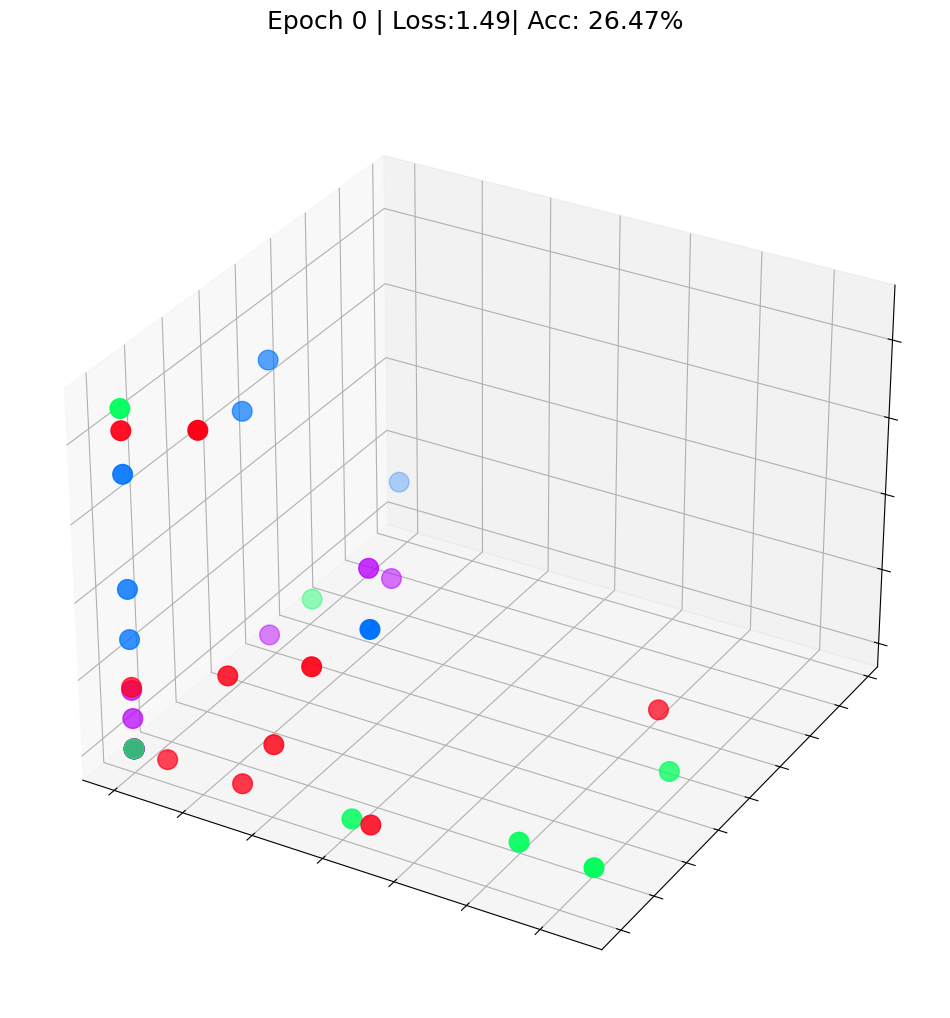

In [ ]:
#3D embeddings visualization
print(f"Final Embeddings = {h.shape}")
print(h)

emb = h.detach().cpu().numpy()

fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(projection='3d')

ax.patch.set_alpha(0)
plt.tick_params(left=False,bottom=False,labelleft=False,labelbottom=False)

ax.scatter(emb[:,0], emb[:,1], emb[:,2],
           s=200,
           c=data.y,
           cmap="hsv",
           vmin=-2,
           vmax=3)

plt.show()


def animate_3d(i):
    emb = embeddings[i].detach().cpu().numpy()
    ax.clear()

    ax.scatter(emb[:,0], emb[:,1], emb[:,2],
               s=200,
               c=data.y,
               cmap="hsv",
               vmin=-2,
               vmax=3)

    plt.title(
        f'Epoch {i} | Loss:{losses[i].item():.2f}| Acc: {accuracies[i].item()*100:.2f}%',
        fontsize=18,
        pad=40
    )


fig = plt.figure(figsize=(12,12))
plt.axis('off')

ax = fig.add_subplot(projection='3d')

plt.tick_params(left=False,bottom=False,labelleft=False,labelbottom=False)

anim = animation.FuncAnimation(
    fig,
    animate_3d,
    np.arange(0,200,10),
    interval=800,
    repeat=True
)

html = HTML(anim.to_html5_video())
display(html)